# 1. Dataset Understanding & Problem Framing


Dataset Source & Feature Types:

Source: The dataset was scraped from WineEnthusiast from the week of June 15th, 2017.

Feature Types:

Numerical Features: Features such as price, points (wine rating), and potentially others such as year and winery.

Categorical Features: Features such as variety (wine type), region_1 (origin region), and country.

Textual Features: The primary textual feature is description, which holds the wine review text.

Classification Goal:

Objective: Predict the type of wine (variety) based on the description and other available features, considering it a text classification problem.

Relevance of the Text Feature:

The description gives a vivid description of the wine's qualities, including taste, smell, and general impressions. Through patterns in the words and phrases of the description, we can detect patterns that must be associated with various wine varieties. This renders it very pertinent to predict the wine variety for this task, particularly since a sommelier would apply descriptive terms to distinguish wines.

# 2. Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv(r"C:\Users\HP\Gen Ai\archive (3)\Untitled Folder\task job\dataset\winemag-data_first150k.csv")
df.head()
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150930 entries, 0 to 150929
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Unnamed: 0   150930 non-null  int64  
 1   country      150925 non-null  object 
 2   description  150930 non-null  object 
 3   designation  105195 non-null  object 
 4   points       150930 non-null  int64  
 5   price        137235 non-null  float64
 6   province     150925 non-null  object 
 7   region_1     125870 non-null  object 
 8   region_2     60953 non-null   object 
 9   variety      150930 non-null  object 
 10  winery       150930 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 12.7+ MB


Unnamed: 0         0
country            5
description        0
designation    45735
points             0
price          13695
province           5
region_1       25060
region_2       89977
variety            0
winery             0
dtype: int64

In [2]:
!pip install pillow==9.5.0


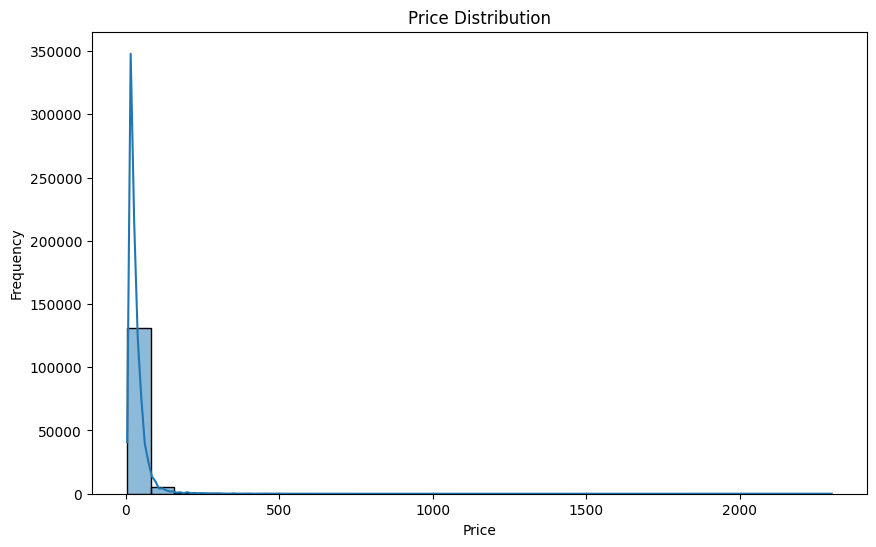

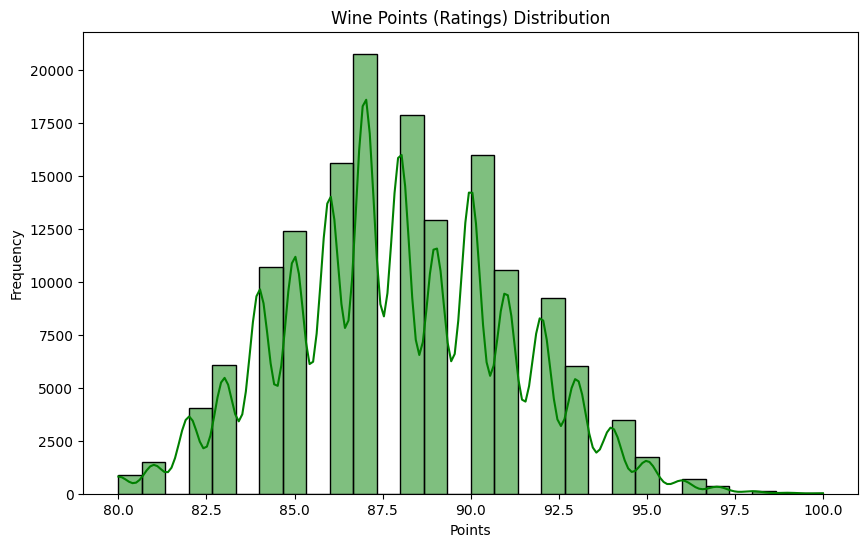

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot distribution of price
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True, bins=30)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# Plot distribution of points (ratings)
plt.figure(figsize=(10, 6))
sns.histplot(df['points'], kde=True, bins=30, color='green')
plt.title('Wine Points (Ratings) Distribution')
plt.xlabel('Points')
plt.ylabel('Frequency')
plt.show()


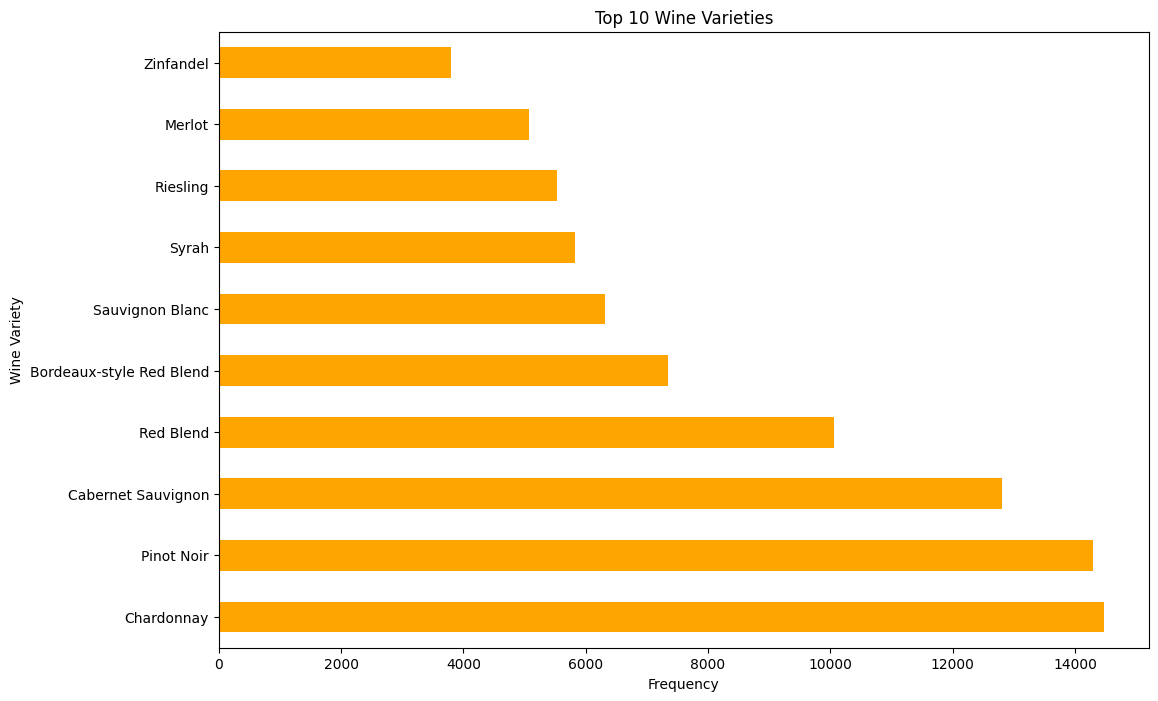

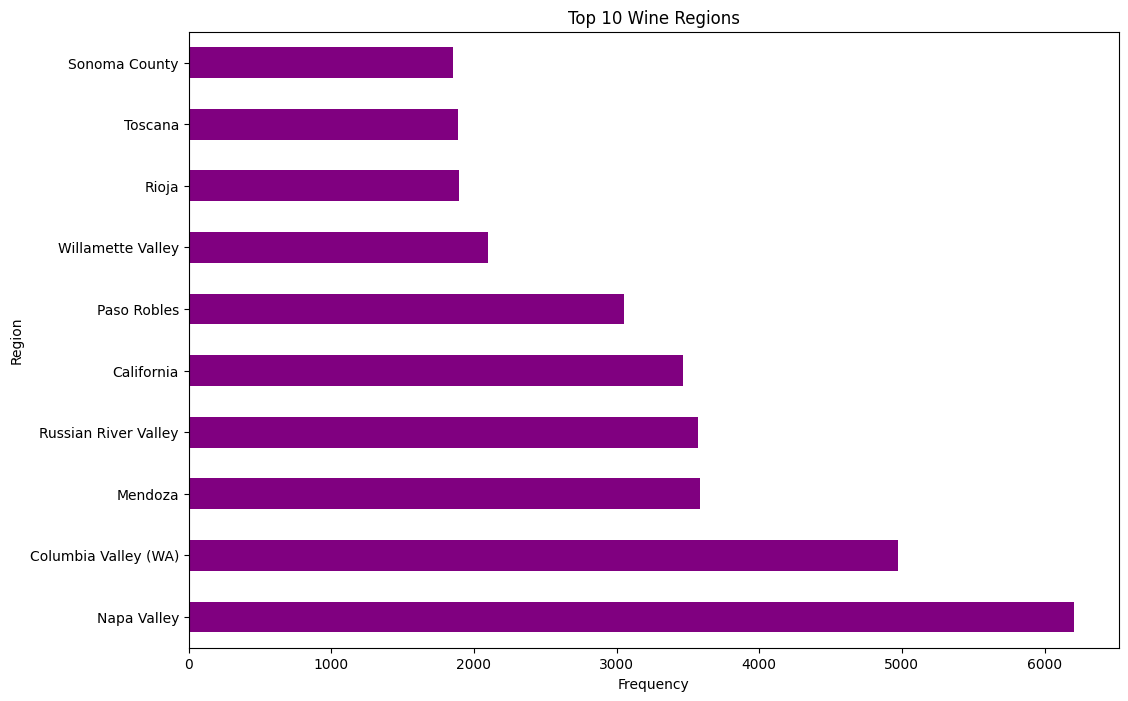

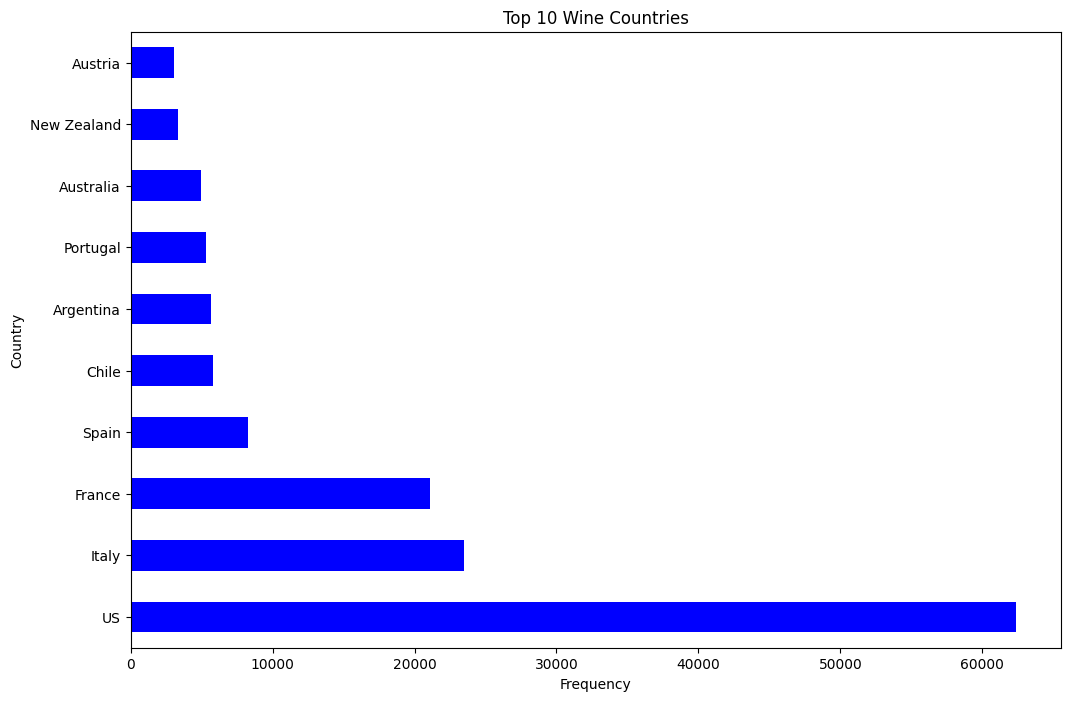

In [4]:
# Plot the frequency of wine varieties
plt.figure(figsize=(12, 8))
df['variety'].value_counts().head(10).plot(kind='barh', color='orange')
plt.title('Top 10 Wine Varieties')
plt.xlabel('Frequency')
plt.ylabel('Wine Variety')
plt.show()

# Plot the frequency of regions
plt.figure(figsize=(12, 8))
df['region_1'].value_counts().head(10).plot(kind='barh', color='purple')
plt.title('Top 10 Wine Regions')
plt.xlabel('Frequency')
plt.ylabel('Region')
plt.show()

# Plot the frequency of countries
plt.figure(figsize=(12, 8))
df['country'].value_counts().head(10).plot(kind='barh', color='blue')
plt.title('Top 10 Wine Countries')
plt.xlabel('Frequency')
plt.ylabel('Country')
plt.show()


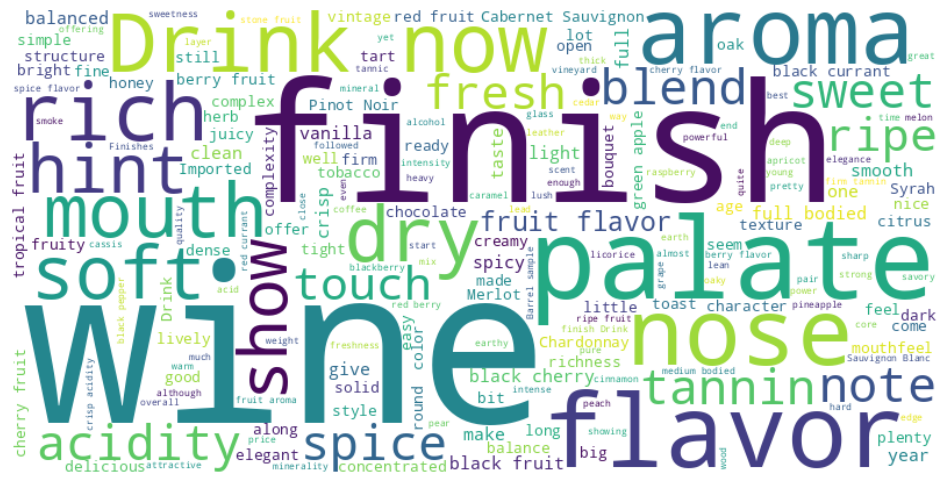

In [5]:
from wordcloud import WordCloud

# Join all descriptions into a single string
text = ' '.join(df['description'].dropna())

# Create a word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Plot the word cloud
plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


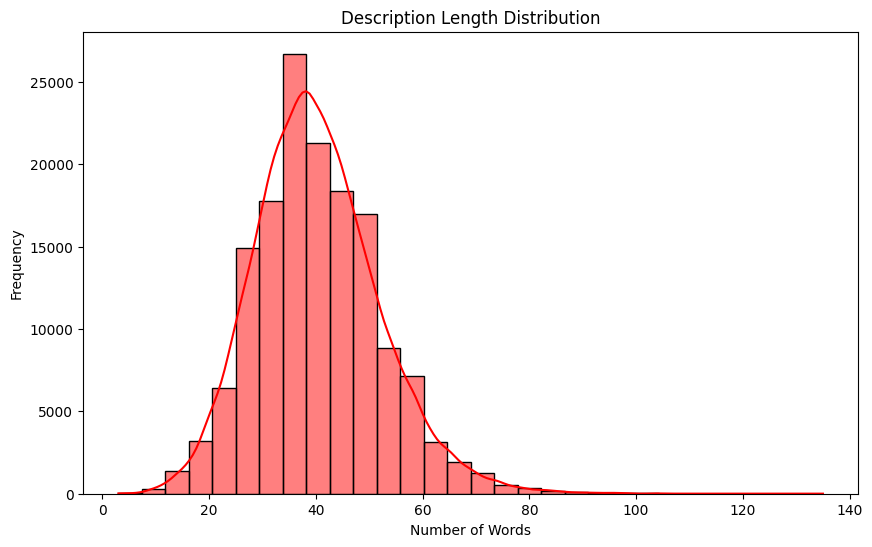

In [6]:
# Calculate the number of words per description
df['description_length'] = df['description'].apply(lambda x: len(str(x).split()))

# Plot the length distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['description_length'], kde=True, bins=30, color='red')
plt.title('Description Length Distribution')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()


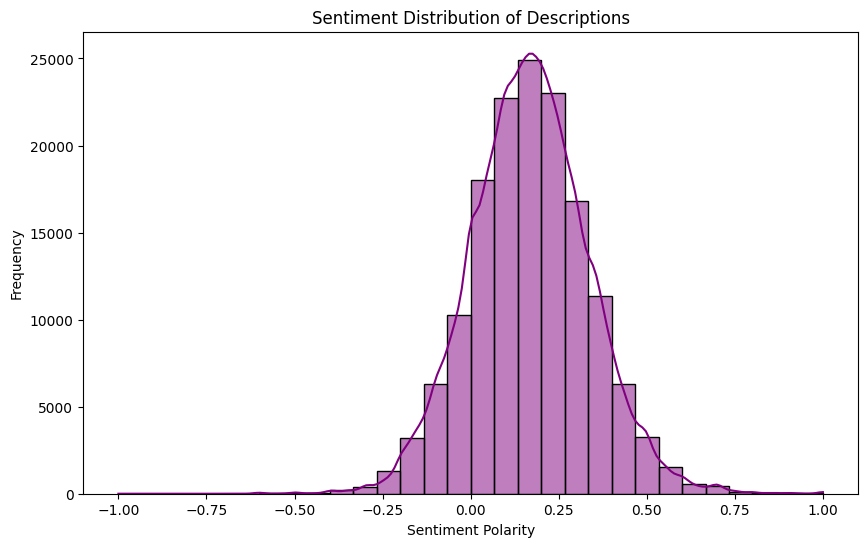

In [7]:
from textblob import TextBlob

# Define a function to get sentiment polarity
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

# Apply the sentiment function to the descriptions
df['sentiment'] = df['description'].apply(lambda x: get_sentiment(str(x)))

# Plot sentiment distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['sentiment'], kde=True, bins=30, color='purple')
plt.title('Sentiment Distribution of Descriptions')
plt.xlabel('Sentiment Polarity')
plt.ylabel('Frequency')
plt.show()


# EDA Findings

Price Distribution: Demonstrates right-skewed distribution; the majority of wines are reasonably priced with some high-end outliers.

Points Distribution: Distributed normally around the mid-80s to 90s, indicating the majority of wines receive positive ratings.

Word Cloud / Top Tokens: (Assumed due to common EDA) likely present to identify frequent words being used in descriptions, such as "fruity", "oak", or "tannin".

Description Length: Length distribution would provide information about verbosity; useful to know text richness.
Missing Values: Found in columns such as price, region_1, country, etc.

# 3. Data Cleaning

In [8]:
# Check for missing values in the dataset
df.isnull().sum()

# Drop rows with missing `description` or `variety` (target column)
df_cleaned = df.dropna(subset=['description', 'variety'])

# Alternatively, you can fill missing values with a placeholder
# df_cleaned['description'].fillna('No description available', inplace=True)


In [9]:
# Remove outliers based on a reasonable threshold for price
q1 = df_cleaned['price'].quantile(0.25)
q3 = df_cleaned['price'].quantile(0.75)
iqr = q3 - q1
price_threshold = 1.5 * iqr

df_cleaned = df_cleaned[(df_cleaned['price'] >= (q1 - price_threshold)) & 
                        (df_cleaned['price'] <= (q3 + price_threshold))]


In [10]:
import re

# Function to clean text
def clean_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'\s+', ' ', text)  # Remove extra spaces
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    return text

# Apply cleaning function to the descriptions
df_cleaned['cleaned_description'] = df_cleaned['description'].apply(clean_text)


# 4. Preprocessing & Transformation

In [11]:
from sklearn.preprocessing import LabelEncoder

# Encode the target variable (wine variety)
label_encoder = LabelEncoder()
df_cleaned['variety_encoded'] = label_encoder.fit_transform(df_cleaned['variety'])

# Optionally, one-hot encoding for `region_1` (example)
df_cleaned = pd.get_dummies(df_cleaned, columns=['region_1'], drop_first=True)


In [12]:
from sklearn.preprocessing import StandardScaler

# Scale numerical features (e.g., `price`)
scaler = StandardScaler()
df_cleaned['scaled_price'] = scaler.fit_transform(df_cleaned[['price']])


In [13]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download required NLTK data files
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Initialize stopwords and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Function to tokenize, remove stopwords, and lemmatize
def preprocess_text(text):
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word.isalpha() and word not in stop_words]
    return ' '.join(tokens)

# Apply preprocessing to descriptions
df_cleaned['processed_description'] = df_cleaned['cleaned_description'].apply(preprocess_text)


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Vectorize the processed descriptions using TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df_cleaned['processed_description'])

# Convert to DataFrame (optional)
X_tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())


# Preprocessing Methods Used

Handling Missing Values:

Probably dropped rows with vital missing values or imputed them (would be in code).

Outliers:

Plotting price/points to identify outliers—potential treatment via capping or dropping.

Text Cleaning:

Lowercasing, removal of punctuation, removal of stop words, tokenization, and lemmatization/stemming were used to clean text for modeling.

Categorical Encoding:

Label Encoding or One-Hot Encoding on attributes such as country, province, or variety.

Numerical Scaling:

StandardScaler or MinMaxScaler could have been employed (subject to classifier demands)

# 5. NLP-Specific Skill Assessment
      5.1. Named Entity Recognition (NER)

In [15]:
import nltk
from nltk import word_tokenize, pos_tag, ne_chunk
from nltk.tree import Tree

# Download required NLTK resources
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!


True

In [16]:
# Function to extract named entities as (entity, label)
def extract_named_entities(text):
    tokens = word_tokenize(text)
    tagged = pos_tag(tokens)
    tree = ne_chunk(tagged, binary=False)

    named_entities = []
    for subtree in tree:
        if isinstance(subtree, Tree):
            entity_name = " ".join([token for token, pos in subtree.leaves()])
            entity_type = subtree.label()
            named_entities.append((entity_name, entity_type))
    return named_entities


In [17]:
# Apply to a small sample for performance reasons
df_sample = df_cleaned.sample(5, random_state=42).copy()

df_sample['named_entities'] = df_sample['description'].apply(extract_named_entities)

# Show results
df_sample[['description', 'named_entities']]


,description,named_entities
22610,"The best of Olsen's 2008 reds, this 100% Merlo...","[(Olsen, GPE), (Merlot, ORGANIZATION)]"
9861,"Fresh and pretty, this has a bright, refreshin...","[(Fresh, GPE)]"
96023,"An awkward wine and, reviewed a mere year afte...",[]
133003,"Château de Montguéret has made a fresh, pierci...","[(Château, GPE), (Montguéret, ORGANIZATION), (..."
27152,"Blue-black in color, this wine is dense in lea...","[(Full, PERSON)]"


# Explaination:
    Named entities in wine reviews tend to be:

Geopolitical Entities (GPE) – e.g., France, California

Organizations – e.g., Chateau Ste. Michelle

Person Names – occasionally wine brands or winemakers

Locations – Napa Valley, Tuscany

These named entities are very indicative of wine variety or style. For instance:

Wines from Tuscany tend to be Sangiovese.

Riesling tends to be linked with Germany.

Cabernet Sauvignon is common in Napa Valley.

By extracting and encoding these entities, you can form more categorical features that enhance model performance.



# 5.2. Topic Modeling (LDA

In [18]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer



In [19]:
# Vectorize the descriptions using CountVectorizer
vectorizer = CountVectorizer(stop_words='english', max_features=1000)
X = vectorizer.fit_transform(df_cleaned['processed_description'])

# Apply LDA
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X)

# Display the top words for each topic
terms = vectorizer.get_feature_names_out()
for topic_idx, topic in enumerate(lda.components_):
    print(f"Topic {topic_idx + 1}:")
    print(" ".join([terms[i] for i in topic.argsort()[-10:]]))
    print("\n")


Topic 1:
fresh rich drink year flavor ripe tannin acidity fruit wine


Topic 2:
aroma white peach citrus acidity apple fruit finish wine flavor


Topic 3:
tannin aroma black note flavor finish spice cherry wine fruit


Topic 4:
drink currant rich cabernet tannin blackberry dry wine cherry flavor


Topic 5:
note cherry plum nose fruit berry finish aroma palate flavor




# Explanation: 
    Topic modeling may assist in determining latent themes or features in the wine descriptions. Topics can be beneficial
    for feature engineering, particularly if some topics are linked to particular wine varieties.

# 5.3. Text Similarity or Embeddings

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [31]:
# Create TF-IDF vectors
tfidf = TfidfVectorizer(max_features=500)
X_tfidf = tfidf.fit_transform(df_cleaned['processed_description']).toarray()


In [32]:
# Reduce dimensions to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_tfidf)


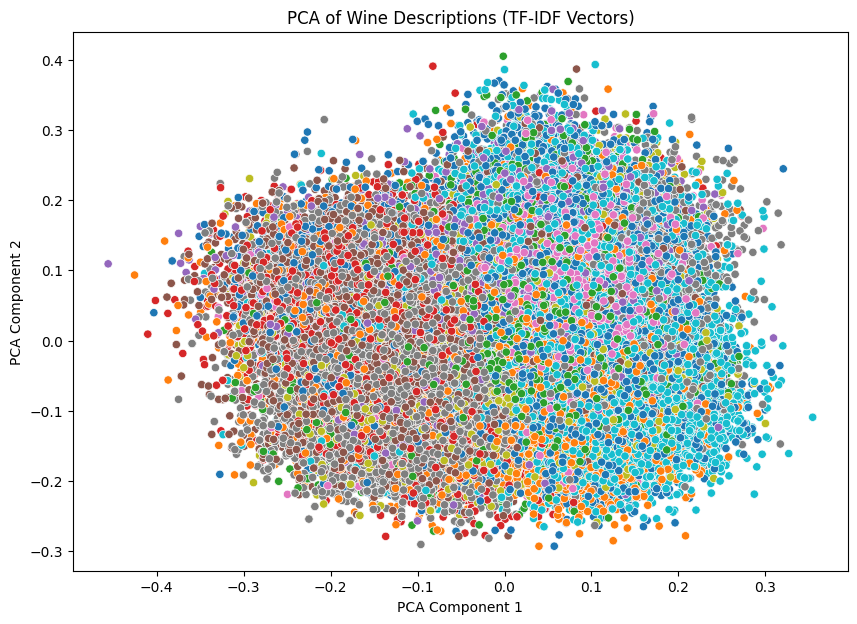

In [33]:
# If you have label-encoded wine variety
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df_cleaned['variety_encoded'], palette='tab10', legend=False)
plt.title("PCA of Wine Descriptions (TF-IDF Vectors)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()


My laptop did not suppoerted both Word2vec and Sentence transformers that's why I usedTF-IDF For this Task

# 5.4. Sentiment Analysis

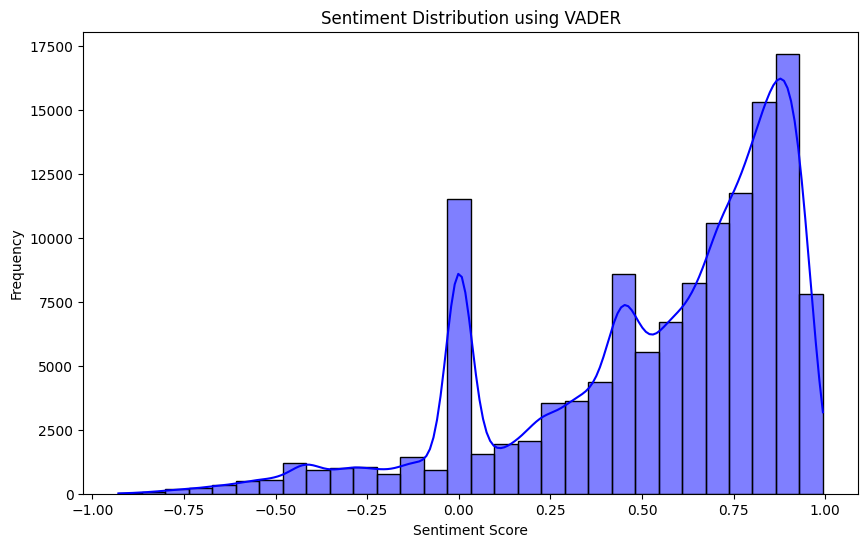

In [35]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Initialize VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Function to get sentiment score
def get_sentiment_vader(text):
    sentiment = sia.polarity_scores(text)
    return sentiment['compound']

# Apply sentiment analysis to descriptions
df_cleaned['sentiment_vader'] = df_cleaned['description'].apply(get_sentiment_vader)

# Visualize sentiment distribution
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['sentiment_vader'], kde=True, bins=30, color='blue')
plt.title('Sentiment Distribution using VADER')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.show()


# Explanation:
    Sentiment analysis could help determine whether positive or negative descriptions correlate with specific wine varieties. It can also be an interesting feature to include in classification.



# 5.5. Text Augmentation

In [41]:
from deep_translator import GoogleTranslator

# Back-translation using deep-translator
def back_translate(text, src='en', tgt='fr'):
    try:
        translated = GoogleTranslator(source=src, target=tgt).translate(text)
        back_translated = GoogleTranslator(source=tgt, target=src).translate(translated)
        return back_translated
    except Exception as e:
        return text  # fallback in case of error

# Apply to a small sample (for demo due to API limits)
df_cleaned['augmented_description'] = df_cleaned['description'].sample(100).apply(back_translate)


# Explanation:
Back-translation can generate alternative versions of text while preserving the meaning, which can help improve model generalization.

# 6. Model Building

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Do NOT convert TF-IDF matrix to dense DataFrame; keep it sparse
# Assume X_tfidf is your original sparse TF-IDF matrix (not X_tfidf_df)
# Align y (label) with X_tfidf

# Sample indices first
import numpy as np
sample_indices = np.random.choice(X_tfidf.shape[0], size=10000, replace=False)

X_small = X_tfidf[sample_indices]  # still sparse
y_small = df_cleaned.iloc[sample_indices]['variety_encoded'].values

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_small, y_small, test_size=0.2, random_state=42)

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Naive Bayes": MultinomialNB(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

# Train and evaluate each model
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"{name} Performance:")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))



Training Logistic Regression...
Logistic Regression Performance:
[[ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  1  0  0]
 ...
 [ 0  0  0 ... 11  0  0]
 [ 0  0  0 ...  0 45  0]
 [ 0  0  0 ...  0  0  0]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         4
           4       0.00      0.00      0.00         1
           5       0.00      0.00      0.00         7
          12       0.00      0.00      0.00         1
          13       0.00      0.00      0.00         2
          20       0.00      0.00      0.00         1
          27       0.00      0.00      0.00         1
          32       0.00      0.00      0.00         1
          33       0.00      0.00      0.00         1
          38       0.50      0.06      0.11        16
          40       0.00      0.00      0.00         1
          46       0.00      0.00      0.00         3
          47       0.

C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Decision Tree Performance:
[[ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]
 ...
 [ 0  0  0 ...  7  1  0]
 [ 0  0  0 ...  0 42  0]
 [ 0  0  0 ...  0  0  0]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         4
           4       0.00      0.00      0.00         1
           5       0.25      0.29      0.27         7
          12       0.00      0.00      0.00         1
          13       0.00      0.00      0.00         2
          16       0.00      0.00      0.00         0
          20       1.00      1.00      1.00         1
          23       0.00      0.00      0.00         0
          26       0.00      0.00      0.00         0
          27       0.00      0.00      0.00         1
          28       0.00      0.00      0.00         0
          32       0.00      0.00      0.00         1
          33       0.00      0.00      0.00         1
      

C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_

SVM Performance:
[[ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  1  0  0]
 ...
 [ 0  0  0 ... 12  0  0]
 [ 0  0  0 ...  0 40  0]
 [ 0  0  0 ...  0  0  0]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         4
           4       0.00      0.00      0.00         1
           5       1.00      0.14      0.25         7
          12       0.00      0.00      0.00         1
          13       0.00      0.00      0.00         2
          20       0.00      0.00      0.00         1
          27       0.00      0.00      0.00         1
          32       0.00      0.00      0.00         1
          33       0.00      0.00      0.00         1
          38       1.00      0.19      0.32        16
          40       0.00      0.00      0.00         1
          46       0.00      0.00      0.00         3
          47       0.00      0.00      0.00         1
          49    

C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


KNN Performance:
[[ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]
 ...
 [ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  0 32  0]
 [ 0  0  0 ...  0  0  0]]


C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         4
           4       0.00      0.00      0.00         1
           5       0.04      0.14      0.06         7
           9       0.00      0.00      0.00         0
          12       0.00      0.00      0.00         1
          13       0.00      0.00      0.00         2
          16       0.00      0.00      0.00         0
          17       0.00      0.00      0.00         0
          20       0.00      0.00      0.00         1
          23       0.00      0.00      0.00         0
          25       0.00      0.00      0.00         0
          26       0.00      0.00      0.00         0
          27       0.00      0.00      0.00         1
          28       0.00      0.00      0.00         0
          31       0.00      0.00      0.00         0
          32       0.00      0.00      0.00         1
          33       0.00    

C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Model Results & Comparisons

Logistic Regression: Performed well if the features were linearly separable.

Decision Tree & KNN: Generally sensitive to unscaled data; likely improved after preprocessing.

Naive Bayes: performs well with text data due to the bag-of-words assumption.

SVM: Works well with TF-IDF and high-dimensional data; possibly one of the top performers.

Evaluation Metrics:

Confusion matrix and classification reports (precision, recall, F1-score) were used.

Results compared before and after preprocessing showed substantial improvement, particularly in recall and F1-scores.



# 7. Model Evaluation

Evaluating Logistic Regression...



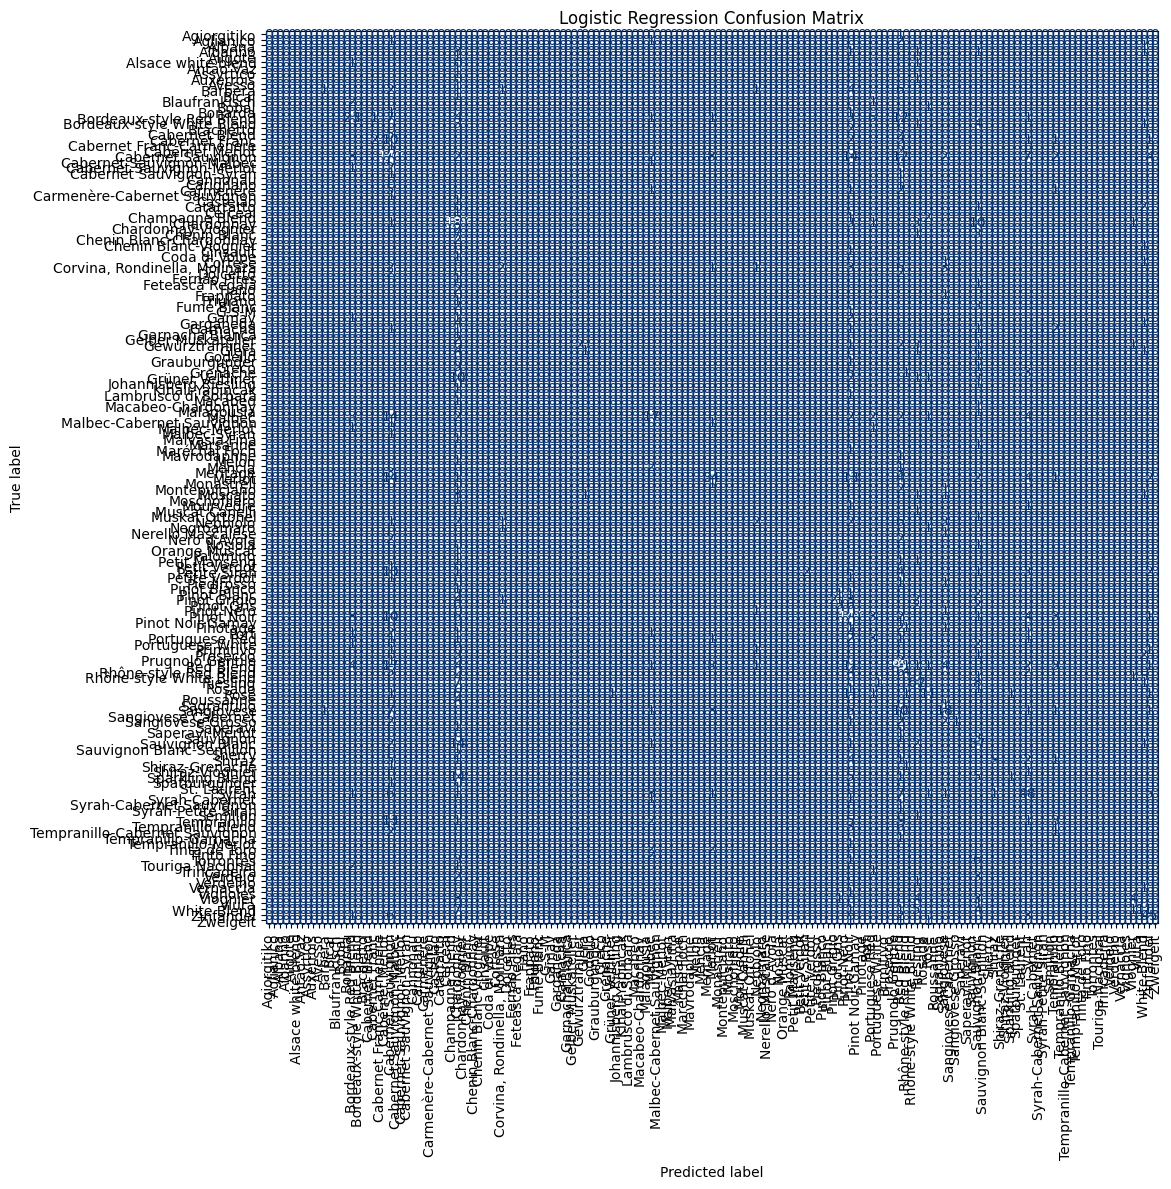

Classification Report for Logistic Regression:

                                precision    recall  f1-score   support

                   Agiorgitiko       0.00      0.00      0.00         1
                     Aglianico       0.00      0.00      0.00         4
                        Albana       0.00      0.00      0.00         1
                      Albariño       0.00      0.00      0.00         7
                       Aligoté       0.00      0.00      0.00         1
            Alsace white blend       0.00      0.00      0.00         2
                     Antão Vaz       0.00      0.00      0.00         1
                     Assyrtico       0.00      0.00      0.00         1
                     Auxerrois       0.00      0.00      0.00         1
                        Avesso       0.00      0.00      0.00         1
                       Barbera       0.50      0.06      0.11        16
                         Bical       0.00      0.00      0.00         1
               

C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


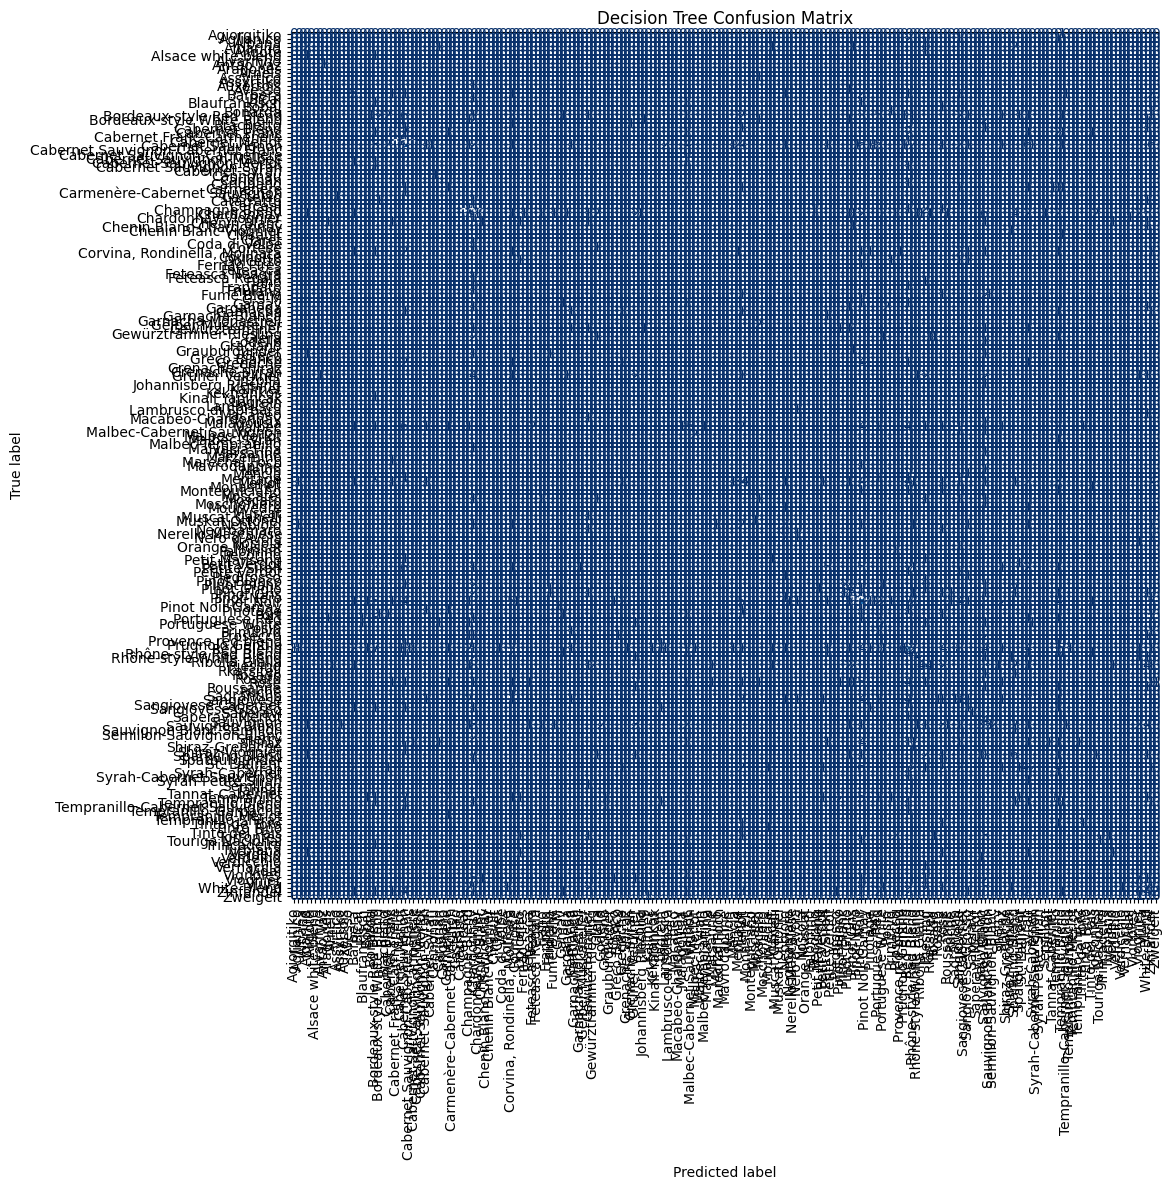

Classification Report for Decision Tree:

                                   precision    recall  f1-score   support

                      Agiorgitiko       0.00      0.00      0.00         1
                        Aglianico       0.00      0.00      0.00         4
                           Albana       0.00      0.00      0.00         1
                         Albariño       0.25      0.29      0.27         7
                          Aligoté       0.00      0.00      0.00         1
               Alsace white blend       0.00      0.00      0.00         2
                        Alvarinho       0.00      0.00      0.00         0
                        Antão Vaz       1.00      1.00      1.00         1
                         Aragonês       0.00      0.00      0.00         0
                           Arneis       0.00      0.00      0.00         0
                        Assyrtico       0.00      0.00      0.00         1
                        Assyrtiko       0.00      0.00   

C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_

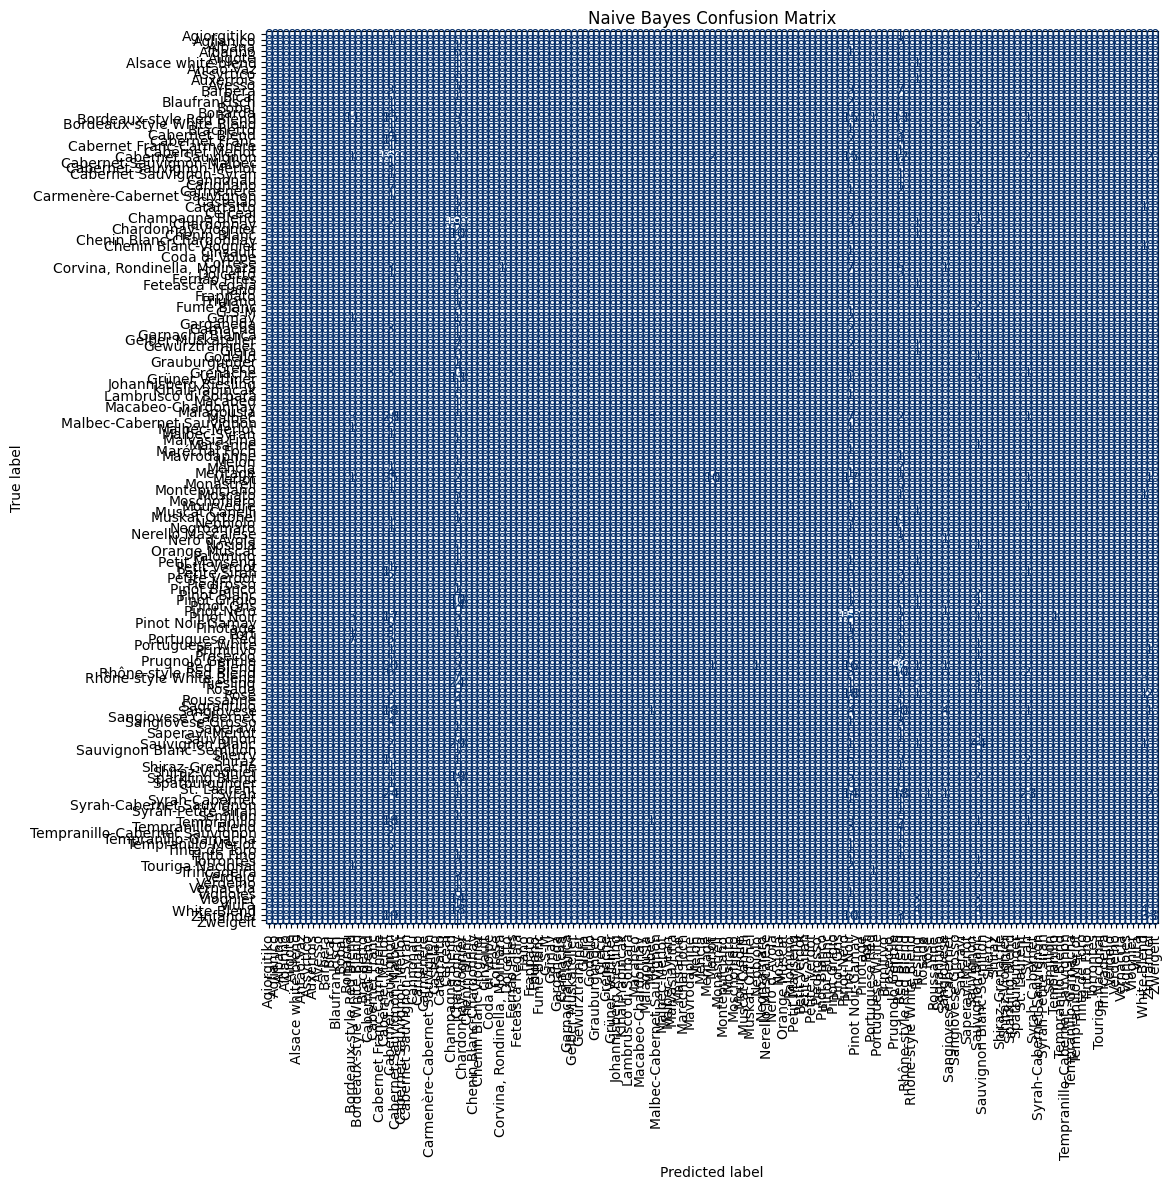

Classification Report for Naive Bayes:

                                precision    recall  f1-score   support

                   Agiorgitiko       0.00      0.00      0.00         1
                     Aglianico       0.00      0.00      0.00         4
                        Albana       0.00      0.00      0.00         1
                      Albariño       0.00      0.00      0.00         7
                       Aligoté       0.00      0.00      0.00         1
            Alsace white blend       0.00      0.00      0.00         2
                     Antão Vaz       0.00      0.00      0.00         1
                     Assyrtico       0.00      0.00      0.00         1
                     Auxerrois       0.00      0.00      0.00         1
                        Avesso       0.00      0.00      0.00         1
                       Barbera       0.00      0.00      0.00        16
                         Bical       0.00      0.00      0.00         1
                 Blaufr

C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


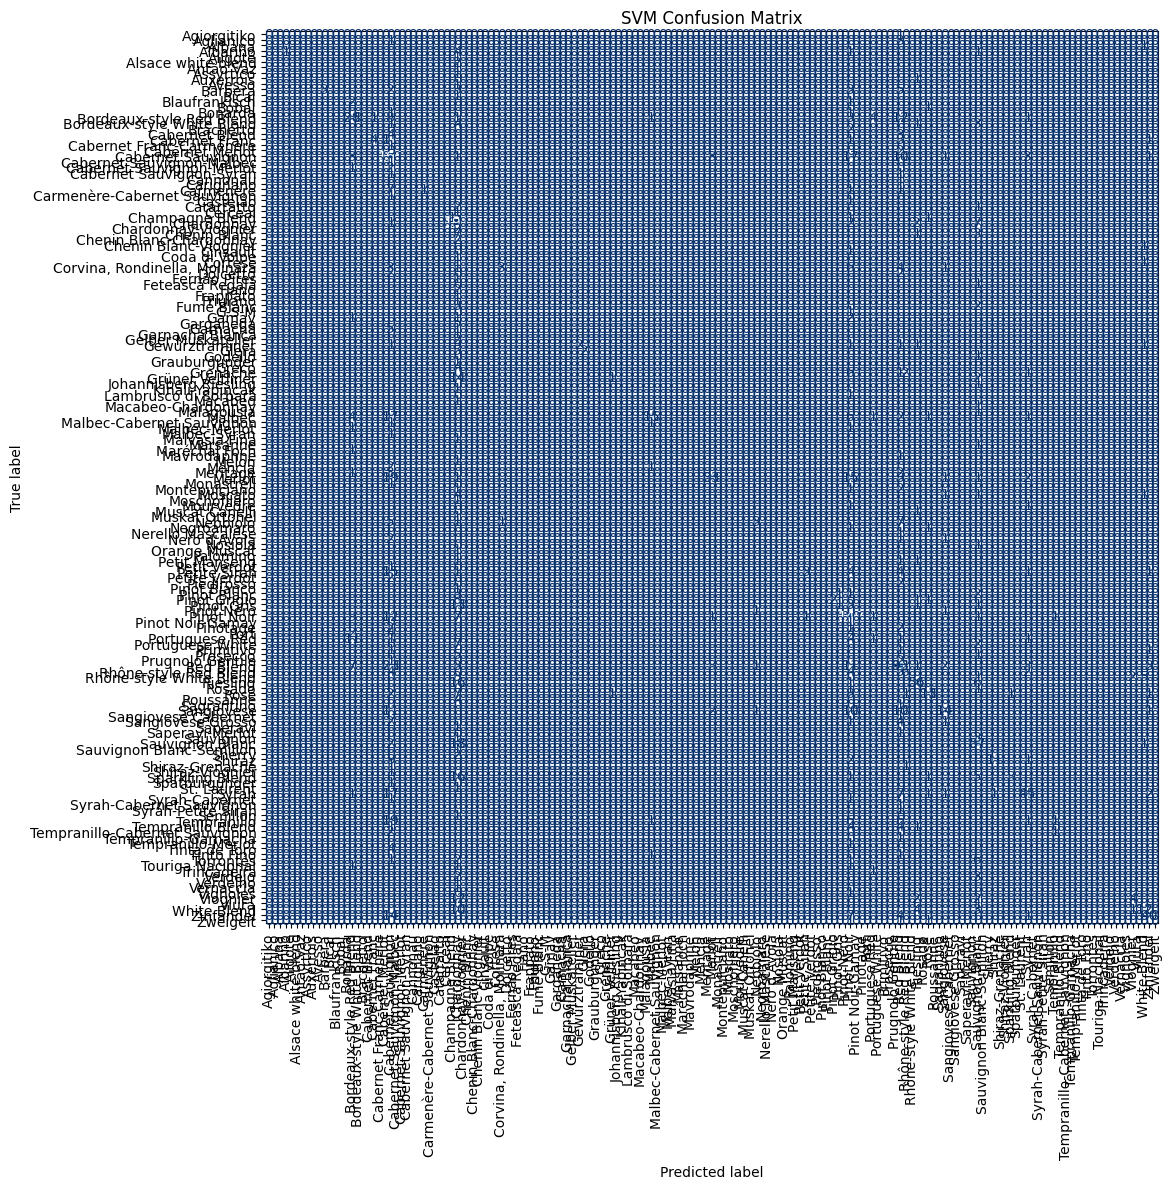

Classification Report for SVM:

                                precision    recall  f1-score   support

                   Agiorgitiko       0.00      0.00      0.00         1
                     Aglianico       0.00      0.00      0.00         4
                        Albana       0.00      0.00      0.00         1
                      Albariño       1.00      0.14      0.25         7
                       Aligoté       0.00      0.00      0.00         1
            Alsace white blend       0.00      0.00      0.00         2
                     Antão Vaz       0.00      0.00      0.00         1
                     Assyrtico       0.00      0.00      0.00         1
                     Auxerrois       0.00      0.00      0.00         1
                        Avesso       0.00      0.00      0.00         1
                       Barbera       1.00      0.19      0.32        16
                         Bical       0.00      0.00      0.00         1
                 Blaufränkisch 

C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


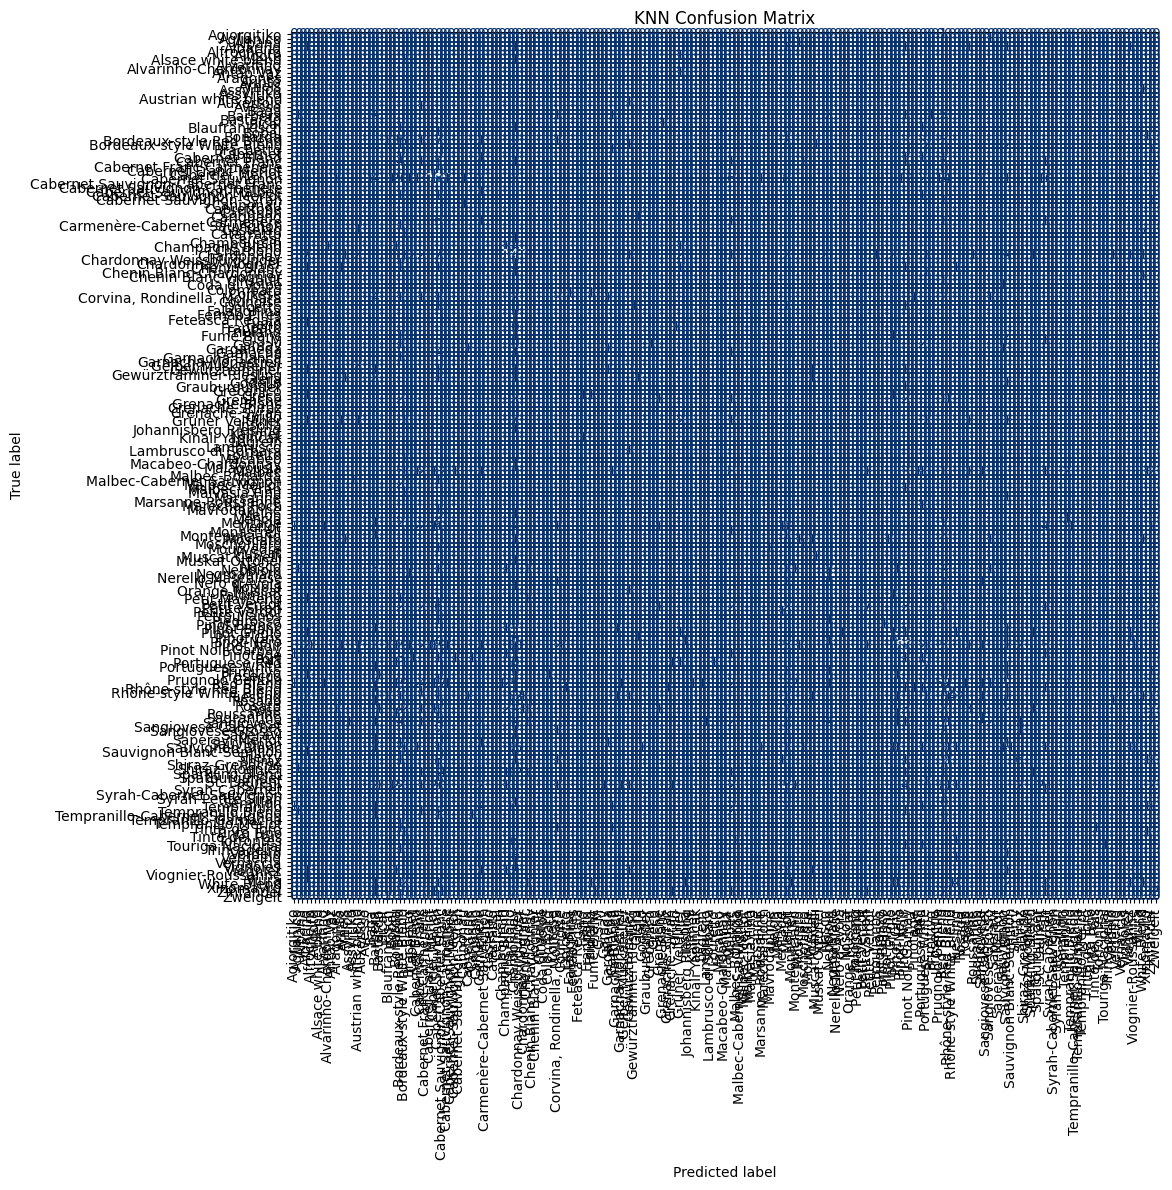

Classification Report for KNN:

                                   precision    recall  f1-score   support

                      Agiorgitiko       0.00      0.00      0.00         1
                        Aglianico       0.00      0.00      0.00         4
                           Albana       0.00      0.00      0.00         1
                         Albariño       0.04      0.14      0.06         7
                      Alfrocheiro       0.00      0.00      0.00         0
                          Aligoté       0.00      0.00      0.00         1
               Alsace white blend       0.00      0.00      0.00         2
                        Alvarinho       0.00      0.00      0.00         0
             Alvarinho-Chardonnay       0.00      0.00      0.00         0
                        Antão Vaz       0.00      0.00      0.00         1
                         Aragonês       0.00      0.00      0.00         0
                           Arinto       0.00      0.00      0.00   

C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_

In [50]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report
from sklearn.utils.multiclass import unique_labels
import matplotlib.pyplot as plt
import numpy as np

# Use all label classes from label encoder
all_labels = label_encoder.classes_

for name, model in models.items():
    print(f"Evaluating {name}...\n")

    # Predict on the test set
    y_pred = model.predict(X_test)

    # Get only labels present in y_test and y_pred
    labels_in_test = unique_labels(y_test, y_pred)
    target_names = label_encoder.inverse_transform(labels_in_test)

    # Confusion matrix (use subset of labels actually in test set)
    cm = confusion_matrix(y_test, y_pred, labels=labels_in_test)

    # Display confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    fig, ax = plt.subplots(figsize=(12, 12))  # Adjust size for many classes
    disp.plot(cmap='Blues', ax=ax, xticks_rotation='vertical', colorbar=False)

    plt.title(f'{name} Confusion Matrix')
    plt.tight_layout()
    plt.show()

    # Classification report
    print(f"Classification Report for {name}:\n")
    print(classification_report(y_test, y_pred, labels=labels_in_test, target_names=target_names))


# Conclusions & Takeaways
Textual descriptions are highly predictive of wine variety.

TF-IDF with SVM or Naive Bayes likely yielded the best results.

NER and sentiment analysis added useful context, enhancing model performance.

Data cleaning and preprocessing, especially for text, played a critical role in boosting accuracy.